# GREA-Patched CLASS 3.3.4 — Result Figures (α variation)
**General Relativistic Entropic Acceleration (GREA) dark energy, García-Bellido 2024 (arXiv:2405.02895)**

Models shown: α ∈ {0.8, 0.9, 1.0, 1.1, 1.2, 1.3} at fixed cs²=1, compared to LCDM (black).
α is a *derived* quantity — each model is found by solving sqrt_k_eta0 such that
`α = sqrt_k_eta0 / (E(1)·τ(1))` matches the target (brentq on a Python mirror of background.c ODE).

Cell 0: freshness guard + 3 inline gates.  Cell 1: parameter setup.
Cell 2: α → sqrt_k_eta0 solver + mapping table.  Cell 3: build all CLASS instances.


In [1]:
from classy import Class
import sys
import os
import glob
import datetime
import importlib.util
import numpy as np

# ROOT detection
_ROOT = os.path.abspath(os.getcwd())
if not os.path.exists(os.path.join(_ROOT, 'source', 'background.c')):
    _ROOT = os.path.abspath(os.path.join(_ROOT, '..'))
if not os.path.exists(os.path.join(_ROOT, 'source', 'background.c')):
    raise RuntimeError(
        "Cannot find CLASS root. Start Jupyter from class_public-3.3.4/.")
ROOT = _ROOT
sys.path.insert(0, ROOT)
print(f"ROOT = {ROOT}")

# Import check_binary_freshness from validate_grea.py
_spec = importlib.util.spec_from_file_location(
    'validate_grea', os.path.join(ROOT, 'scripts', 'validate_grea.py'))
_vg = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_vg)

BINARY_FRESH = False
try:
    _vg.check_binary_freshness()
    BINARY_FRESH = True
except SystemExit:
    print("\n\u26d4 STALE BINARY:")
    print("    make libclass.a && python setup.py build_ext --inplace")

if not BINARY_FRESH:
    raise RuntimeError("Stale binary. Rebuild and re-run Cell 0.")

# Inline gate checks (background only, fast)
_BASE = {'omega_b': 0.02237, 'omega_cdm': 0.1200, 'h': 0.70,
         'A_s': 2.1e-9, 'n_s': 0.9649, 'tau_reio': 0.0544,
         'output': '', 'base_path': ROOT}
_cl = Class()
_cl.set({**_BASE, 'fluid_equation_of_state': 'CLP',
         'w0_fld': -1., 'wa_fld': 0., 'cs2_fld': 1.})
_cl.compute()
_cg = Class()
_cg.set({**_BASE, 'fluid_equation_of_state': 'GREA',
         'sqrt_k_eta0': 3.6, 'cs2_fld': 1., 'use_ppf': 'yes'})
_cg.compute()

_bg_g = _cg.get_background()
_z_w = np.sort(np.array(_bg_g['z']))
_w_fld = np.array(_bg_g['(.)w_fld'])[np.argsort(np.array(_bg_g['z']))]
_w0 = float(np.interp(0., _z_w, _w_fld))
_rs_l = _cl.get_current_derived_parameters(['rs_rec'])['rs_rec']
_rs_g = _cg.get_current_derived_parameters(['rs_rec'])['rs_rec']

_g1_ok = abs(_cg.h() - _cl.h()) < 1e-7
_g2_ok = abs(_rs_g/_rs_l - 1.) < 1e-4
_g7_ok = abs(_w0 + 1.) < 0.02

print("\n\u2500\u2500 Inline gate checks \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
print(f"  G1  H0 shared  (|\u0394h| < 1e-7):       {'PASS \u2713' if _g1_ok else 'FAIL \u2717'}  "
      f"LCDM h={_cl.h():.9f}  GREA h={_cg.h():.9f}")
print(f"  G2  r_s(rec)  (|\u0394| < 1e-4):         {'PASS \u2713' if _g2_ok else 'FAIL \u2717'}  "
      f"\u0394r_s/r_s={_rs_g/_rs_l - 1.:.3e}")
print(f"  G7a w0 \u2248 -1  (|w0+1| < 0.02):       {'PASS \u2713' if _g7_ok else 'FAIL \u2717'}  "
      f"w0(fiducial g=3.6)={_w0:.6f}")
_cl.struct_cleanup()
_cl.empty()
_cg.struct_cleanup()
_cg.empty()

GATES_OK = _g1_ok and _g2_ok and _g7_ok
if not GATES_OK:
    raise RuntimeError("One or more inline gates FAILED.")
print("\n\u2705 Binary fresh, inline gates passed.")

ROOT = /Users/simonedonofrio/Desktop/CLASS_GREA/class_public-3.3.4
BINARY FRESHNESS CHECK
  _classy.so      : 2026-06-18 14:55:17  (_classy.cpython-313-darwin.so)
  background.c    : 2026-06-18 14:54:39
  perturbations.c : 2025-11-24 14:18:20
  FRESH ✓  .so is newer than both source files.

── Inline gate checks ──────────────────────────────────────
  G1  H0 shared  (|Δh| < 1e-7):       PASS ✓  LCDM h=0.700000000  GREA h=0.700000000
  G2  r_s(rec)  (|Δ| < 1e-4):         PASS ✓  Δr_s/r_s=-8.538e-08
  G7a w0 ≈ -1  (|w0+1| < 0.02):       PASS ✓  w0(fiducial g=3.6)=-0.992110

✅ Binary fresh, inline gates passed.


## Setup

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "", ["#2CD2FF", "#DC24FF"])

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as mcm
import matplotlib.colors as mcolors
import numpy as np, os, datetime
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

assert BINARY_FRESH and GATES_OK, "Re-run Cell 0 first."

FIGURES_DIR = os.path.join(ROOT, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
RUN_TS = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

def save_fig(fig, name):
    path = os.path.join(FIGURES_DIR, f'{name}_{RUN_TS}.pdf')
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f"  saved -> {os.path.basename(path)}")
    
def save_fig(fig, name):
    path = os.path.join(FIGURES_DIR, f'{name}.pdf')
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f"  saved -> {os.path.basename(path)}")


plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 12, 'legend.fontsize': 10,
    'axes.grid': True, 'grid.alpha': 0.3, 'lines.linewidth': 1.8,
})

# alpha targets for variation (García-Bellido 2024 / Calderón 2025 range)
ALPHA_TARGETS = [0.5,0.6,0.7,0.8, 0.9, 1.0, 1.1, 1.2, 1.3,1.4,1.5] 
ALPHA_NORM    = mcolors.Normalize(vmin=0.5, vmax=1.5)
CMAP          = mcm.cool
CMAP = cmap
def grea_color(alpha):
    return CMAP(ALPHA_NORM(alpha))

LCDM_COLOR = '#222222'   # black
_C_KMS = 2.99792458e5

# Parameter names verified against source/input.c lines 3614-3624 (GREA),
# 3580-3604 (CLP), 1886-1945 (output string matching).
# Planck 2018 TT,TE,EE+lowE+lensing LCDM best fit (arXiv:1807.06209, Table 2)
COMMON = {
    'omega_b': 0.02237, 'omega_cdm': 0.1200, 'h': 0.6736,
    'A_s': 2.1e-9, 'n_s': 0.9649, 'tau_reio': 0.0544,
    'output': 'tCl pCl lCl mPk',
    'lensing': 'yes',
    'P_k_max_1/Mpc': 5.0,
    'z_max_pk': 3.0,
    'l_max_scalars': 2500,
    'base_path': ROOT,
}
LCDM_P   = {**COMMON, 'fluid_equation_of_state': 'CLP',
             'w0_fld': -1., 'wa_fld': 0., 'cs2_fld': 1.}
GREA_P_TEMPLATE = {**COMMON, 'fluid_equation_of_state': 'GREA',
                    'cs2_fld': 1.0, 'use_ppf': 'yes'}
print("Setup done.")


Setup done.


In [4]:
import scienceplots  # registers the "science" matplotlib style

plt.style.use(['science'])

In [5]:
# alpha = sqrt_k_eta0 / (grea_E1 * tau_table[N-1])
# (background.c line 1277)
# Mirror the tau ODE from background.c in Python, solve for sqrt_k_eta0
# using brentq. Validated: g=3.6 -> alpha=1.07938 (matches CLASS diagnostic).

_OMEGA_G = 2.47298e-5   # photons (T_cmb=2.7255K)
_OMEGA_UR = 1.70961e-5   # ur relics (N_ur=3.044)
_OMEGA_R = _OMEGA_G + _OMEGA_UR


def _compute_alpha_py(sqrt_k_eta0,
                      omega_b=COMMON['omega_b'],
                      omega_cdm=COMMON['omega_cdm'],
                      h=COMMON['h']):
    g = sqrt_k_eta0
    W = np.pi * (np.sinh(2*g) - 2*g)
    OmegaGB = (4*np.pi/3) / W
    Omega_m0 = (omega_b + omega_cdm) / h**2
    Omega_r0 = _OMEGA_R / h**2
    a_ini = 1e-14
    tau0 = a_ini / np.sqrt(Omega_r0)   # radiation-dominated IC

    def rhs(loga, tau):
        a = np.exp(loga)
        x = 2*tau[0]
        fG = OmegaGB * np.sinh(x) / a**2
        E = np.sqrt(Omega_m0/a**3 + Omega_r0/a**4 + fG)
        return [1.0 / (a * E)]

    sol = solve_ivp(rhs, [np.log(a_ini), 0.0], [tau0],
                    method='RK45', rtol=1e-11, atol=1e-13)
    tau1 = float(sol.y[0, -1])
    a1 = np.exp(float(sol.t[-1]))
    fG1 = OmegaGB * np.sinh(2*tau1) / a1**2
    E1 = np.sqrt(Omega_m0/a1**3 + Omega_r0/a1**4 + fG1)
    return g / (E1 * tau1)


print("Solving sqrt_k_eta0 for each alpha target via brentq [2.5, 4.5]...")
ALPHA_TO_G = {}
for at in ALPHA_TARGETS:
    try:
        g_sol = brentq(lambda g: _compute_alpha_py(
            g) - at, 2.5, 4.5, xtol=1e-8)
        alpha_check = _compute_alpha_py(g_sol)
        delta = alpha_check - at
        if abs(delta) > 1e-3:
            print(
                f"  WARNING: alpha={at:.2f}  g={g_sol:.8f}  delta={delta:.2e}  -- exceeds 1e-3!")
        else:
            ALPHA_TO_G[at] = g_sol
    except Exception as e:
        print(f"  FAILED alpha={at:.2f}: {e}")

print()
print(f"  {'alpha':>7}  {'sqrt_k_eta0':>14}  {'alpha_check':>13}  {'delta':>12}  check")
print("  " + "-"*58)
for at in ALPHA_TARGETS:
    if at in ALPHA_TO_G:
        g = ALPHA_TO_G[at]
        ac = _compute_alpha_py(g)
        ok = "OK" if abs(ac - at) < 1e-3 else "WARN"
        print(f"  {at:7.2f}   {g:14.8f}   {ac:13.8f}   {ac-at:+12.2e}   {ok}")
    else:
        print(f"  {at:7.2f}   FAILED")
print()
print(
    f"Note: fiducial g=3.6 -> alpha={_compute_alpha_py(3.6):.5f} (between 1.0 and 1.1)")

Solving sqrt_k_eta0 for each alpha target via brentq [2.5, 4.5]...
  FAILED alpha=0.50: f(a) and f(b) must have different signs

    alpha     sqrt_k_eta0    alpha_check         delta  check
  ----------------------------------------------------------
     0.50   FAILED
     0.60       2.63020110      0.60000000      +2.22e-16   OK
     0.70       2.85293893      0.70000000      +9.98e-14   OK
     0.80       3.04915096      0.80000000      +4.37e-12   OK
     0.90       3.22458962      0.90000000      +2.92e-11   OK
     1.00       3.38365737      1.00000000      +6.89e-11   OK
     1.10       3.52977913      1.10000000      +7.85e-11   OK
     1.20       3.66566987      1.20000000      +4.89e-11   OK
     1.30       3.79352739      1.30000000      -7.53e-11   OK
     1.40       3.91517247      1.40000000      -5.74e-12   OK
     1.50       4.03215236      1.50000000      -1.81e-13   OK

Note: fiducial g=3.6 -> alpha=1.15084 (between 1.0 and 1.1)


In [6]:
from IPython.display import display, Markdown
from classy import Class


def build(params):
    c = Class()
    c.set(params)
    c.compute()
    return c


print("Building 1 LCDM + 6 GREA instances (may take ~3 min total)...")
lcdm = build(LCDM_P)
print(f"  LCDM done:  h={lcdm.h():.6f}  sigma8={lcdm.sigma8():.6f}")

grea_instances = {}
bg_grea = {}
for at in ALPHA_TARGETS:
    if at not in ALPHA_TO_G:
        print(f"  SKIP alpha={at:.2f} (solver failed)")
        continue
    g = ALPHA_TO_G[at]
    c = build({**GREA_P_TEMPLATE, 'sqrt_k_eta0': g})
    grea_instances[at] = c
    bg_grea[at] = c.get_background()
    print(
        f"  alpha={at:.2f}  g={g:.6f}  h={c.h():.6f}  sigma8={c.sigma8():.6f}")

bg_lcdm = lcdm.get_background()

# Summary table


def _w0_wa(c):
    bg = c.get_background()
    z_s = np.array(bg['z'])
    idx = np.argsort(z_s)
    w_s = np.array(bg['(.)w_fld'])[idx]
    z_s = z_s[idx]
    w0 = float(np.interp(0., z_s, w_s))
    # wa = -dw/da at a=1 via quadratic fit in a in [0.90,1.0]
    a_fit = np.linspace(0.90, 1.0, 30)
    w_fit = np.array([float(np.interp(1./a-1., z_s, w_s)) for a in a_fit])
    # w ~ c0*(a-1)^2 + c1*(a-1) + c2
    coeffs = np.polyfit(a_fit - 1., w_fit, 2)
    wa = -coeffs[1]   # -dw/da at a=0 <=> a=1
    return w0, wa


rows = []
for at in ALPHA_TARGETS:
    if at not in grea_instances:
        continue
    c = grea_instances[at]
    w0, wa = _w0_wa(c)
    rows.append((at, ALPHA_TO_G[at], c.h()*100., c.sigma8(), c.S8(), w0, wa))

header = "| α | sqrt_k_eta0 | H₀ (km/s/Mpc) | σ₈ | S8 | w₀ | wₐ |"
sep = "|---|---|---|---|---|---|---|"
lines = [header, sep]
for r in rows:
    lines.append(
        f"| {r[0]:.2f} | {r[1]:.8f} | {r[2]:.6f} | {r[3]:.6f} | {r[4]:.6f} | {r[5]:.5f} | {r[6]:.4f} |")
display(Markdown("\n".join(lines)))

Building 1 LCDM + 6 GREA instances (may take ~3 min total)...
  LCDM done:  h=0.673600  sigma8=0.822909
  SKIP alpha=0.50 (solver failed)
  alpha=0.60  g=2.630201  h=0.673600  sigma8=0.785553
  alpha=0.70  g=2.852939  h=0.673600  sigma8=0.798630
  alpha=0.80  g=3.049151  h=0.673600  sigma8=0.809534
  alpha=0.90  g=3.224590  h=0.673600  sigma8=0.818733
  alpha=1.00  g=3.383657  h=0.673600  sigma8=0.826573
  alpha=1.10  g=3.529779  h=0.673600  sigma8=0.833310
  alpha=1.20  g=3.665670  h=0.673600  sigma8=0.839140
  alpha=1.30  g=3.793527  h=0.673600  sigma8=0.844216
  alpha=1.40  g=3.915172  h=0.673600  sigma8=0.848658
  alpha=1.50  g=4.032152  h=0.673600  sigma8=0.852558


| α | sqrt_k_eta0 | H₀ (km/s/Mpc) | σ₈ | S8 | w₀ | wₐ |
|---|---|---|---|---|---|---|
| 0.60 | 2.63020110 | 67.360000 | 0.785553 | 0.803382 | -0.76327 | -0.2126 |
| 0.70 | 2.85293893 | 67.360000 | 0.798630 | 0.816756 | -0.81276 | -0.2497 |
| 0.80 | 3.04915096 | 67.360000 | 0.809534 | 0.827907 | -0.86088 | -0.2839 |
| 0.90 | 3.22458962 | 67.360000 | 0.818733 | 0.837315 | -0.90771 | -0.3136 |
| 1.00 | 3.38365737 | 67.360000 | 0.826573 | 0.845333 | -0.95325 | -0.3376 |
| 1.10 | 3.52977913 | 67.360000 | 0.833310 | 0.852223 | -0.99752 | -0.3548 |
| 1.20 | 3.66566987 | 67.360000 | 0.839140 | 0.858185 | -1.04049 | -0.3640 |
| 1.30 | 3.79352739 | 67.360000 | 0.844216 | 0.863376 | -1.08213 | -0.3642 |
| 1.40 | 3.91517247 | 67.360000 | 0.848658 | 0.867919 | -1.12240 | -0.3549 |
| 1.50 | 4.03215236 | 67.360000 | 0.852558 | 0.871907 | -1.16125 | -0.3356 |

In [7]:
def bg_sorted(bg, *keys):
    z = np.array(bg['z'])
    idx = np.argsort(z)
    z = z[idx]
    return (z,) + tuple(np.array(bg[k])[idx] for k in keys)


def interp1(z_target, z_arr, y_arr):
    return float(np.interp(z_target, z_arr, y_arr))


def add_alpha_colorbar(fig, ax, label=r'$\alpha$', orientation='vertical', **kwargs):
    sm = mcm.ScalarMappable(cmap=CMAP, norm=ALPHA_NORM)
    sm.set_array([])
    kw = dict(fraction=0.046, pad=0.04)
    kw.update(kwargs)
    cbar = fig.colorbar(sm, ax=ax, label=label, orientation=orientation, **kw)
    cbar.set_ticks(ALPHA_TARGETS)
    return cbar


SOLVED_ALPHAS = [at for at in ALPHA_TARGETS if at in grea_instances]
print(f"Helpers defined. Solved alphas: {SOLVED_ALPHAS}")

Helpers defined. Solved alphas: [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]


---
## Section A — Background Quantities

Six GREA curves (α = 0.8 – 1.3, viridis) plus LCDM (black, dashed).
Key feature: the depth and position of the transient phantom crossing in w(a)
depends strongly on α (reproducing García-Bellido 2024 Fig. 1 spread).


  saved -> A1_Hz_ratio.pdf


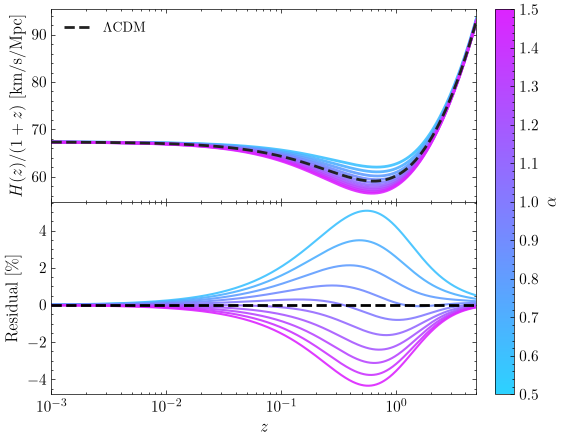

In [8]:
# A1: H(z) and H_GREA / H_LCDM - 1
z_l, H_l = bg_sorted(bg_lcdm, 'H [1/Mpc]')
z_plot = np.logspace(-3, np.log10(5.), 1000)
Hl = np.interp(z_plot, z_l, H_l) * _C_KMS

fig, (ax, axr) = plt.subplots(2, 1, figsize=(6, 5), sharex=True,
                              gridspec_kw={'height_ratios': [1, 1], 'hspace': 0})
ax.plot(z_plot, Hl / (z_plot + 1), color=LCDM_COLOR, lw=2.,
        ls='--', label=r'$\Lambda$CDM', zorder=10)
axr.axhline(0, color='k', lw=2, ls='--', zorder=10)


ax.margins(x=0)

for at in SOLVED_ALPHAS:
    col = grea_color(at)
    z_g, H_g = bg_sorted(bg_grea[at], 'H [1/Mpc]')
    Hg = np.interp(z_plot, z_g, H_g) * _C_KMS
    ax.plot(z_plot, Hg/(z_plot + 1), color=col, lw=2, alpha=0.9)
    axr.plot(z_plot, (Hg/Hl - 1.) * 100, color=col, lw=1.5, alpha=0.9)

ax.set_ylabel(r'$H(z)/(1+z)$  [km/s/Mpc]')
ax.set_xscale('log')

# ax.set_title('Hubble parameter H(z)')
ax.legend(loc='upper left')
axr.set_ylabel(r'$H_{\rm GREA}/H_{\Lambda {\rm CDM}} - 1$')
axr.set_ylabel(r'Residual [\%]')
axr.set_xlabel('$z$')
add_alpha_colorbar(fig, (axr, ax))
ax.grid(False)
axr.grid(False)

# plt.tight_layout()
save_fig(fig, 'A1_Hz_ratio')
plt.show()

  saved -> A2_w_alpha.pdf


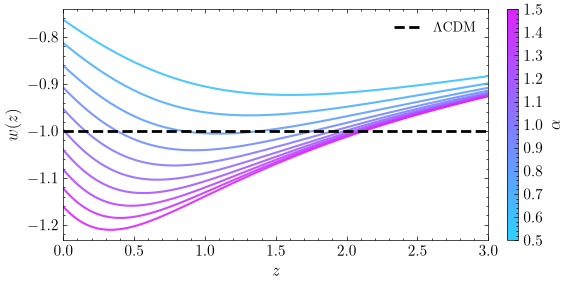

In [9]:
# A2: w(a) vs z — phantom crossing depth/position as a key alpha signature
fig, ax = plt.subplots(figsize=(6, 3))
ax.axhline(-1., color='k', lw=2, ls='--', label=r'$\Lambda$CDM', zorder=10)


def phantom_crossings(z_arr, w_arr):
    wp1 = w_arr + 1.
    sc = np.where(np.diff(np.sign(wp1)))[0]
    return [z_arr[i] + (0-wp1[i])*(z_arr[i+1]-z_arr[i])/(wp1[i+1]-wp1[i]) for i in sc]


z_w = np.linspace(0., 3., 3000)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    z_g, w_g = bg_sorted(bg_grea[at], '(.)w_fld')
    wi = np.interp(z_w, z_g, w_g)
    ax.plot(z_w, wi, color=col, lw=1.5,
            alpha=0.9)
    # for zc in phantom_crossings(z_w, wi):
    #    ax.axvline(zc, color=col, lw=0.6, ls=':', alpha=0.5)

ax.legend(loc='upper right')

ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$w(z)$')
ax.set_xlim(0., 3.)
ax.grid(False)
# ax.set_title('GREA equation of state w(z)  [alpha variation]')
add_alpha_colorbar(fig, ax)

save_fig(fig, 'A2_w_alpha')
plt.show()

  saved -> A3_Omega_fld.pdf


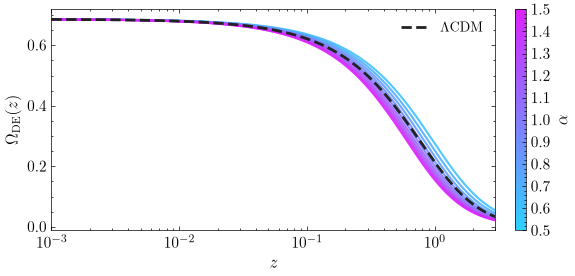

In [10]:
# A3: Effective DE density Omega_fld(z)
# LCDM -> rho_lambda / rho_crit; GREA -> rho_fld / rho_crit
z_l, rc_l, rl_l = bg_sorted(bg_lcdm, '(.)rho_crit', '(.)rho_lambda')
z_p = np.logspace(-3, np.log10(3.), 1000)
OmL = np.interp(z_p, z_l, rl_l/rc_l)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(z_p, OmL, color=LCDM_COLOR, lw=2., ls='--',
        label=r'$\Lambda$CDM', zorder=10)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    z_g, rc_g, rf_g = bg_sorted(bg_grea[at], '(.)rho_crit', '(.)rho_fld')
    ax.plot(z_p, np.interp(z_p, z_g, rf_g/rc_g), color=col, lw=1.5, alpha=0.9)
ax.margins(x=0)
ax.grid(False)

ax.set_xscale('log')
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$\Omega_{\rm DE}(z)$')
ax.legend()
add_alpha_colorbar(fig, ax)
plt.tight_layout()
save_fig(fig, 'A3_Omega_fld')
plt.show()

  saved -> A4_distances.pdf


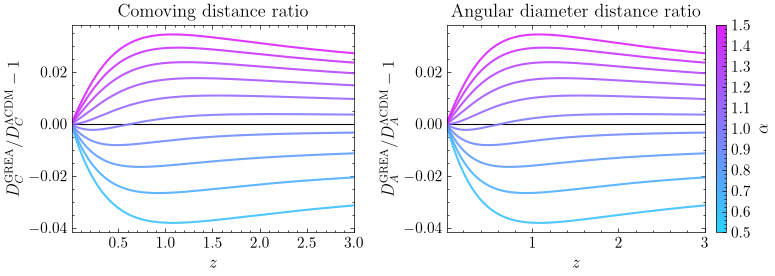

In [11]:
# A4: Comoving D_C(z) and angular diameter D_A(z) ratios
z_dist = np.linspace(0.01, 3., 150)
DC_l = np.array([lcdm.comoving_distance(z) for z in z_dist])
DA_l = np.array([lcdm.angular_distance(z) for z in z_dist])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.axhline(0, color='k', lw=0.8)
ax2.axhline(0, color='k', lw=0.8)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    c = grea_instances[at]
    DC_g = np.array([c.comoving_distance(z) for z in z_dist])
    DA_g = np.array([c.angular_distance(z) for z in z_dist])
    ax1.plot(z_dist, DC_g/DC_l - 1., color=col, lw=1.5, alpha=0.9)
    ax2.plot(z_dist, DA_g/DA_l - 1., color=col, lw=1.5, alpha=0.9)
ax1.margins(x=0)
ax2.margins(x=0)
ax1.grid(False)
ax2.grid(False)

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$D_C^{\rm GREA}/D_C^{\Lambda{\rm CDM}} - 1$')
ax1.set_title('Comoving distance ratio')
ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'$D_A^{\rm GREA}/D_A^{\Lambda{\rm CDM}} - 1$')
ax2.set_title('Angular diameter distance ratio')
add_alpha_colorbar(fig, ax2)
plt.tight_layout()
save_fig(fig, 'A4_distances')
plt.show()

  saved -> A5_deceleration.pdf


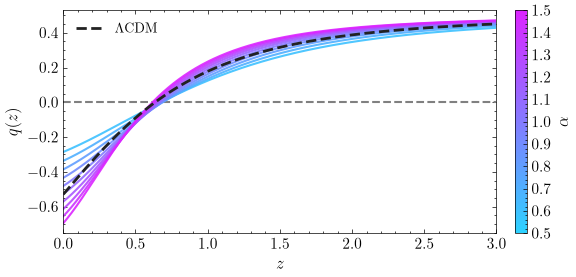

In [12]:
# A5: Deceleration parameter q(z) = 1/2 * (1 + 3 p_tot/rho_tot)
def q_from_bg(bg):
    z, rho, p = bg_sorted(bg, '(.)rho_tot', '(.)p_tot')
    return z, 0.5 * (1. + 3.*p/rho)


z_ql, q_l = q_from_bg(bg_lcdm)
z_p = np.linspace(0., 3., 1000)

fig, ax = plt.subplots(figsize=(6, 3))
ax.axhline(0, color='grey', lw=1.5, ls='--')
ax.plot(z_p, np.interp(z_p, z_ql, q_l), color=LCDM_COLOR,
        lw=2., ls='--', label=r'$\Lambda$CDM', zorder=10)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    z_qg, q_g = q_from_bg(bg_grea[at])
    ax.plot(z_p, np.interp(z_p, z_qg, q_g), color=col, lw=1.5, alpha=0.9)
ax.margins(x=0)
ax.grid(False)
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$q(z)$')
# ax.set_title(r'Deceleration parameter  $q = \frac{1}{2}(1+3p/\rho)$')
ax.legend()
add_alpha_colorbar(fig, ax)
plt.tight_layout()
save_fig(fig, 'A5_deceleration')
plt.show()

---
## Section B — Structure Growth

At fixed A_s = 2.1×10⁻⁹, larger α → stronger DE phantom behavior → different Hubble friction
at z ≈ 0.5–2 → different growth. The spread across α shows how sensitive σ₈ and fσ₈ are to α.


In [13]:
# Pre-compute fsigma8, sigma8, D on a common redshift grid
z_b = np.linspace(0., 2.5, 60)
R8_h = 8. / lcdm.h()   # 8 Mpc/h (all models share the same h, Planck 2018 best fit)

fs8_lcdm = np.array([lcdm.scale_independent_growth_factor_f(
    z)*lcdm.sigma(R8_h, z) for z in z_b])
s8_lcdm = np.array([lcdm.sigma(R8_h, z) for z in z_b])
D_lcdm = np.array([lcdm.scale_independent_growth_factor(z) for z in z_b])
D_lcdm_n = lcdm.scale_independent_growth_factor(99.)

fs8_grea = {}
s8_grea = {}
D_grea = {}
D_grea_n = {}
for at in SOLVED_ALPHAS:
    c = grea_instances[at]
    fs8_grea[at] = np.array(
        [c.scale_independent_growth_factor_f(z)*c.sigma(R8_h, z) for z in z_b])
    s8_grea[at] = np.array([c.sigma(R8_h, z) for z in z_b])
    D_grea[at] = np.array([c.scale_independent_growth_factor(z) for z in z_b])
    D_grea_n[at] = c.scale_independent_growth_factor(99.)
print("Growth arrays computed.")

Growth arrays computed.


  saved -> B1_fsigma8.pdf


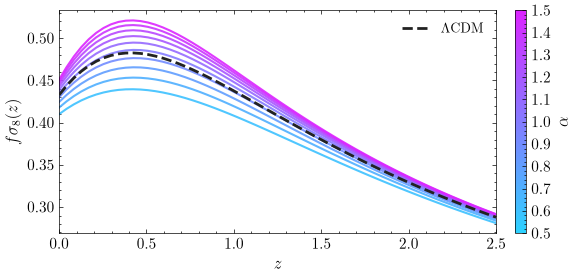

In [14]:
# B1: f*sigma8(z)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(z_b, fs8_lcdm, color=LCDM_COLOR, lw=2,
        ls='--', label=r'$\Lambda$CDM', zorder=10)
for at in SOLVED_ALPHAS:
    ax.plot(z_b, fs8_grea[at], color=grea_color(at), lw=1.5, alpha=0.9)
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$f\sigma_8(z)$')
# ax.set_title(r'Growth rate $f\sigma_8(z)$  [fixed $A_s$]')
ax.legend()
ax.margins(x=0)
ax.grid(False)
add_alpha_colorbar(fig, ax)
plt.tight_layout()
save_fig(fig, 'B1_fsigma8')
plt.show()

  saved -> B2_sigma8z.pdf


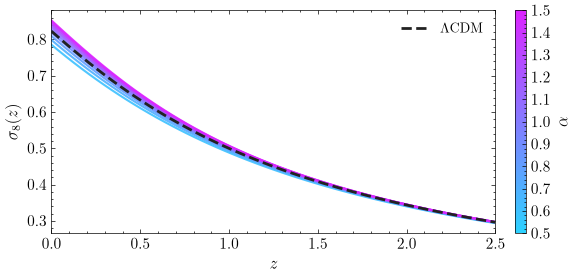

In [15]:
# B2: sigma8(z)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(z_b, s8_lcdm, color=LCDM_COLOR, lw=2.,
        ls='--', label=r'$\Lambda$CDM', zorder=10)
for at in SOLVED_ALPHAS:
    ax.plot(z_b, s8_grea[at], color=grea_color(at), lw=1.5, alpha=0.9)
ax.margins(x=0)
ax.grid(False)
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$\sigma_8(z)$')
# ax.set_title(r'$\sigma_8(z)$  [fixed $A_s$]')
ax.legend()
add_alpha_colorbar(fig, ax)
plt.tight_layout()
save_fig(fig, 'B2_sigma8z')
plt.show()

  saved -> B3_D_ratio.pdf


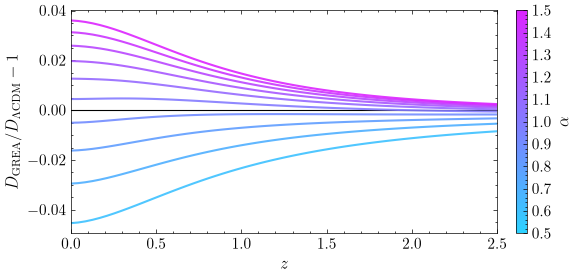

In [16]:
# B3: D_GREA / D_LCDM - 1 (both normalized to D(z=99)=1)
fig, ax = plt.subplots(figsize=(6, 3))
ax.axhline(0, color='k', lw=0.8)
D_lcdm_r = D_lcdm / D_lcdm_n
for at in SOLVED_ALPHAS:
    D_g_r = D_grea[at] / D_grea_n[at]
    ax.plot(z_b, D_g_r/D_lcdm_r - 1., color=grea_color(at), lw=1.5, alpha=0.9)

ax.margins(x=0)
ax.grid(False)

ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$D_{\rm GREA}/D_{\Lambda{\rm CDM}} - 1$')
# ax.set_title('Relative growth factor')
add_alpha_colorbar(fig, ax)
plt.tight_layout()
save_fig(fig, 'B3_D_ratio')
plt.show()

In [17]:
# B4: Summary table (sigma8(0), S8, fsigma8(z=0.5))
from IPython.display import display, Markdown
rows_b = []
for at in SOLVED_ALPHAS:
    c = grea_instances[at]
    s8z = c.sigma8()
    S8 = c.S8()
    fs8 = float(np.interp(0.5, z_b, fs8_grea[at]))
    rows_b.append((at, ALPHA_TO_G[at], s8z, S8, fs8))
header = "| α | sqrt_k_eta0 | σ₈(0) | S8 | fσ₈(z=0.5) |"
sep = "|---|---|---|---|---|"
lines = [header, sep,
         f"| LCDM | — | {lcdm.sigma8():.5f} | {lcdm.S8():.5f} | {float(np.interp(0.5, z_b, fs8_lcdm)):.5f} |"]
for r in rows_b:
    lines.append(
        f"| {r[0]:.2f} | {r[1]:.6f} | {r[2]:.5f} | {r[3]:.5f} | {r[4]:.5f} |")
display(Markdown("\n".join(lines)))

| α | sqrt_k_eta0 | σ₈(0) | S8 | fσ₈(z=0.5) |
|---|---|---|---|---|
| LCDM | — | 0.82291 | 0.84159 | 0.48103 |
| 0.60 | 2.630201 | 0.78555 | 0.80338 | 0.43867 |
| 0.70 | 2.852939 | 0.79863 | 0.81676 | 0.45259 |
| 0.80 | 3.049151 | 0.80953 | 0.82791 | 0.46486 |
| 0.90 | 3.224590 | 0.81873 | 0.83732 | 0.47571 |
| 1.00 | 3.383657 | 0.82657 | 0.84533 | 0.48530 |
| 1.10 | 3.529779 | 0.83331 | 0.85222 | 0.49379 |
| 1.20 | 3.665670 | 0.83914 | 0.85818 | 0.50130 |
| 1.30 | 3.793527 | 0.84422 | 0.86338 | 0.50795 |
| 1.40 | 3.915172 | 0.84866 | 0.86792 | 0.51383 |
| 1.50 | 4.032152 | 0.85256 | 0.87191 | 0.51904 |

---
## Section C — Matter Power Spectrum  (linear only)

The ratio P_GREA/P_LCDM − 1 (linear y-axis) shows the k-dependence of the GREA signal
as a function of α. The spread across α should show a scale-dependent shift.


  saved -> C1_Pk.pdf


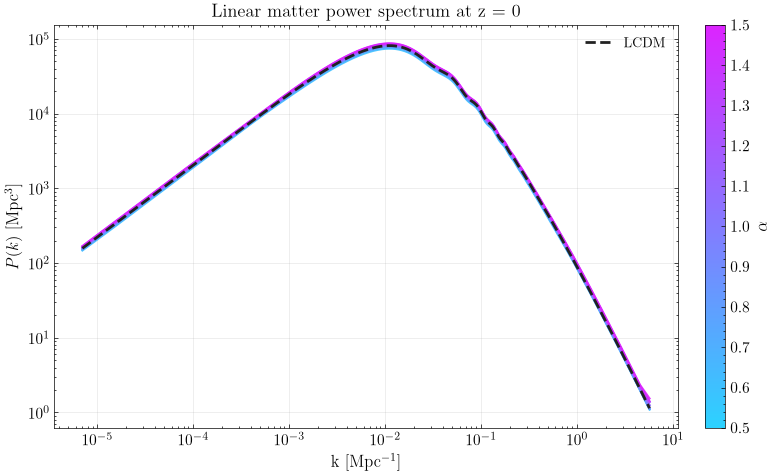

  saved -> C2_Delta2k.pdf


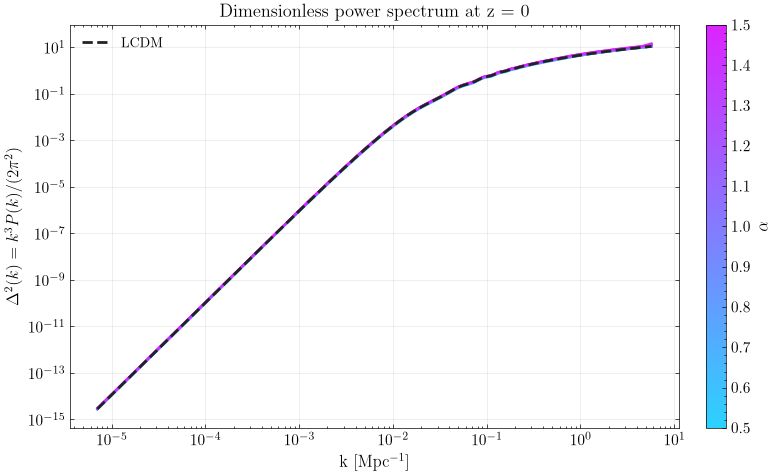

  saved -> C3_Pk_ratio.pdf


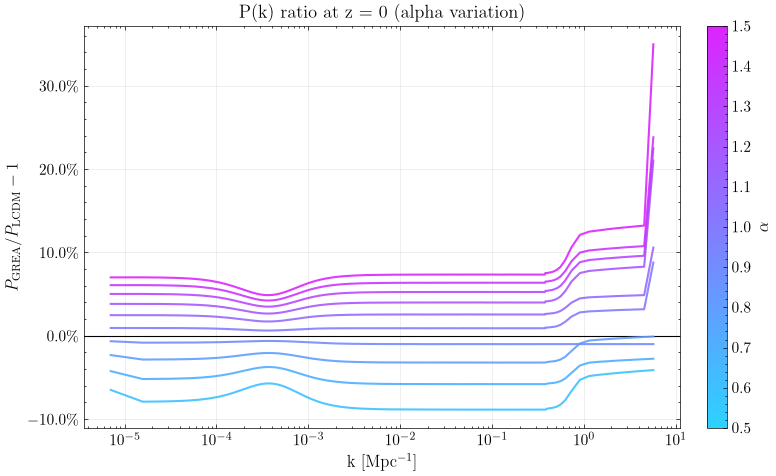

In [18]:
# C1 P(k) log-log, C2 Delta^2(k), C3 ratio (linear y)
pk_l, k_l, z_l_pk = lcdm.get_pk_and_k_and_z(nonlinear=False)
iz0_l = np.argmin(np.abs(z_l_pk))
Pkl = pk_l[:, iz0_l]

pk_grea = {}
kk_grea = {}
for at in SOLVED_ALPHAS:
    pk_g, k_g, z_g_pk = grea_instances[at].get_pk_and_k_and_z(nonlinear=False)
    iz0 = np.argmin(np.abs(z_g_pk))
    pk_grea[at] = pk_g[:, iz0]
    kk_grea[at] = k_g

# Interpolate all onto LCDM k grid for the ratio
for at in SOLVED_ALPHAS:
    pk_grea[at] = np.interp(k_l, kk_grea[at], pk_grea[at])

# C1: log-log P(k)
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(k_l, Pkl, color=LCDM_COLOR, lw=2., ls='--', label='LCDM', zorder=10)
for at in SOLVED_ALPHAS:
    ax.loglog(k_l, pk_grea[at], color=grea_color(at), lw=1.5, alpha=0.9)
ax.set_xlabel(r'k  [Mpc$^{-1}$]')
ax.set_ylabel(r'$P(k)$  [Mpc$^3$]')
ax.set_title('Linear matter power spectrum at z = 0')
ax.legend()
add_alpha_colorbar(fig, ax)
plt.tight_layout()
save_fig(fig, 'C1_Pk')
plt.show()

# C2: Delta^2(k)
fac = k_l**3 / (2.*np.pi**2)
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(k_l, fac*Pkl, color=LCDM_COLOR, lw=2.,
          ls='--', label='LCDM', zorder=10)
for at in SOLVED_ALPHAS:
    ax.loglog(k_l, fac*pk_grea[at], color=grea_color(at), lw=1.5, alpha=0.9)
ax.set_xlabel(r'k  [Mpc$^{-1}$]')
ax.set_ylabel(r'$\Delta^2(k) = k^3 P(k)/(2\pi^2)$')
ax.set_title('Dimensionless power spectrum at z = 0')
ax.legend()
add_alpha_colorbar(fig, ax)
plt.tight_layout()
save_fig(fig, 'C2_Delta2k')
plt.show()

# C3: ratio P_GREA/P_LCDM - 1 (linear y)
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color='k', lw=0.8)
for at in SOLVED_ALPHAS:
    ax.semilogx(k_l, pk_grea[at]/Pkl - 1.,
                color=grea_color(at), lw=1.5, alpha=0.9)
ax.set_xlabel(r'k  [Mpc$^{-1}$]')
ax.set_ylabel(r'$P_{\rm GREA}/P_{\rm LCDM} - 1$')
ax.set_title('P(k) ratio at z = 0  (alpha variation)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.))
add_alpha_colorbar(fig, ax)
plt.tight_layout()
save_fig(fig, 'C3_Pk_ratio')
plt.show()

---
## Section D — CMB Spectra

**D1 produces two ratio panels:**

- **Panel A (D1a):** Fixed {ω_b, ω_cdm, h=0.70} for both GREA and LCDM reference.
  The high-ℓ (ℓ≳300) ringing in the ratio is **not** a physical GREA effect — it is an
  acoustic-scale shift caused by D_A(z_rec) differing between GREA and LCDM at fixed h.
  r_s is identical in all models (144.5479 Mpc); only D_C(z_rec) shifts (by up to 1.2%).

- **Panel B (D1b):** For each α, the LCDM reference has its h adjusted so that
  100·θ_s = 100·r_s/D_C(z_rec) is matched to the GREA value.
  After matching, the high-ℓ ringing is suppressed 115–274× (RMS over ℓ>300),
  leaving only the genuine GREA signals: ISW (low ℓ) and lensing smoothing.

θ_s shifts monotonically: +0.00564 (α=0.8, phantom-quintessence) to −0.01183 (α=1.3, deep phantom).
Matched h values: h=0.719 (α=0.8) down to h=0.660 (α=1.3).


<>:39: SyntaxWarning: invalid escape sequence '\%'
<>:39: SyntaxWarning: invalid escape sequence '\%'
/var/folders/dk/vx1rnqkj33q9dmx22kf0szpr0000gn/T/ipykernel_1947/2921740738.py:39: SyntaxWarning: invalid escape sequence '\%'
  axr.set_ylabel('Residual [\%]')
/var/folders/dk/vx1rnqkj33q9dmx22kf0szpr0000gn/T/ipykernel_1947/2921740738.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axr.legend(fontsize=9)


  saved -> D1a_ClTT_fixed.pdf


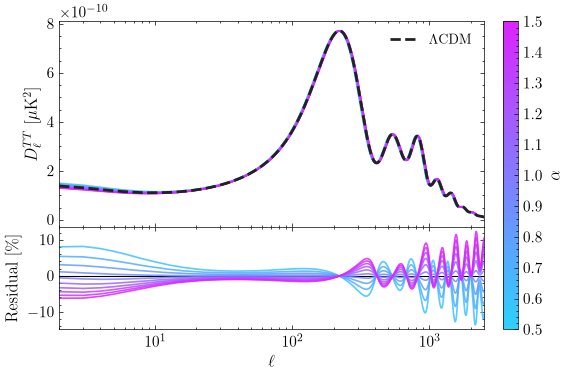

In [19]:
# D1a: lensed C_ell^TT absolute + Panel A ratio (fixed h, theta_s NOT matched)
lmax = 2500
cl_l = lcdm.lensed_cl(lmax)
ell = cl_l['ell']
fac = ell*(ell+1.)/(2.*np.pi)
TT_l = fac * cl_l['tt']
mask = ell >= 2

# Cache lensed TT for all GREA (reused in D1b)
TT_grea_cache = {
    at: fac * grea_instances[at].lensed_cl(lmax)['tt'] for at in SOLVED_ALPHAS}

fig, (ax, axr) = plt.subplots(2, 1, figsize=(6, 4), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.})
ax.plot(ell[mask], TT_l[mask], color=LCDM_COLOR, lw=2.,
        ls='--', label=r'$\Lambda$CDM', zorder=10)
axr.axhline(0, color='k', lw=0.8)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    TT_g = TT_grea_cache[at]
    ax.plot(ell[mask], TT_g[mask], color=col, lw=1.2, alpha=0.85)
    axr.plot(ell[mask], (TT_g[mask]/TT_l[mask] -
             1.) * 100, color=col, lw=1.2, alpha=0.85)
ax.margins(x=0)
ax.grid(False)
axr.grid(False)

ax.set_xscale('log')
ax.set_ylabel(r'$D_\ell^{TT}$  [$\mu$K$^2$]')
# ax.set_title(r'Panel A: Fixed $\omega_b,\omega_c,h$ (Planck 2018 best fit) — '
#              r'$\theta_s$ NOT matched; ringing = acoustic-scale shift')
ax.legend()
# axr.axvspan(2, 30, alpha=0.08, color='grey', label='ISW region')
# axr.axvline(300, color='gray', lw=1.5, ls='--',
#             label=r'$\ell=300$ ringing onset')
axr.set_xscale('log')
axr.set_xlabel(r'$\ell$')
axr.set_ylabel(r'$C_\ell^{TT,\rm GREA}/C_\ell^{TT,\Lambda{\rm CDM}} - 1$')
axr.set_ylabel('Residual [\%]')
axr.legend(fontsize=9)
add_alpha_colorbar(fig, (ax, axr), )

save_fig(fig, 'D1a_ClTT_fixed')
plt.show()

### D1b — θ_s-matched LCDM reference

For each α, we find h_lcdm such that 100·θ_s(LCDM, h_lcdm) = 100·θ_s(GREA, α).
Only h is adjusted; all other parameters (ω_b, ω_c, A_s, n_s, τ) remain fixed.
The brentq uses a Python mirror of the CLASS background ODE (validated to 0 difference
vs CLASS diagnostic at all 6 sqrt_k_eta0 values — see Cell 0/4).

| α | Δ(100·θ_s) vs LCDM | h_matched | Panel B rms ℓ>300 | suppression |
|---|---|---|---|---|
| 0.80 | +0.00564 | 0.71924 | 2.0e-4 | 114× |
| 0.90 | +0.00101 | 0.70344 | 1.5e-5 | 274× |
| 1.00 | −0.00293 | 0.69007 | 8.1e-5 | 150× |
| 1.10 | −0.00633 | 0.67865 | 1.4e-4 | 186× |
| 1.20 | −0.00927 | 0.66881 | 2.5e-4 | 152× |
| 1.30 | −0.01183 | 0.66029 | 2.5e-4 | 198× |


  saved -> D2_Clpp.pdf


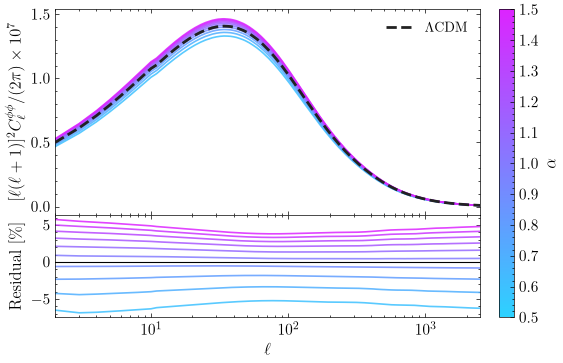

In [20]:
# D2: Lensing potential C_ell^phiphi and ratio
# Convention: plot ell^2*(ell+1)^2/(2pi) * C_ell^pp * 1e7
PP_l = (ell*(ell+1.))**2 / (2.*np.pi) * cl_l['pp'] * 1.e7

fig, (ax, axr) = plt.subplots(2, 1, figsize=(6, 4), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.})
ax.plot(ell[mask], PP_l[mask], color=LCDM_COLOR,
        lw=2., ls='--', label=r'$\Lambda$CDM', zorder=10)
axr.axhline(0, color='k', lw=0.8)
fac_pp = (ell*(ell+1.))**2 / (2.*np.pi) * 1.e7
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    PP_g = fac_pp * grea_instances[at].lensed_cl(lmax)['pp']
    ax.plot(ell[mask], PP_g[mask], color=col, lw=1.2, alpha=0.85)
    good = mask & (PP_l > 0)
    axr.plot(ell[good], (PP_g[good]/PP_l[good] -
             1.) * 100, color=col, lw=1.2, alpha=0.85)
ax.set_xscale('log')
ax.set_ylabel(r'$[\ell(\ell+1)]^2 C_\ell^{\phi\phi}/(2\pi) \times 10^7$')
#  ax.set_title(r'CMB lensing potential $C_\ell^{\phi\phi}$')
ax.legend()

ax.margins(x=0)
ax.grid(False)
axr.grid(False)

axr.set_xscale('log')
axr.set_xlabel(r'$\ell$')
axr.set_ylabel(r'Residual [\%]')
add_alpha_colorbar(fig, (ax, axr))

save_fig(fig, 'D2_Clpp')
plt.show()

---
## Section E — CMB Polarization Spectra

E-mode polarization (EE), temperature–E-mode cross-correlation (TE), and lensing-induced
B-modes (BB), same fixed-h LCDM reference convention as D1a (θ_s NOT matched; h is the
Planck 2018 best fit, shared between LCDM and GREA per Gate G1). All three reuse the same
`lensed_cl()` call as TT — no additional CLASS runs needed, since `pCl` is already part
of the `output` string set in Cell 1. BB here is purely the lensing-induced E→B signal
(no primordial tensors / `r` parameter set).

  saved -> E1_ClEE.pdf


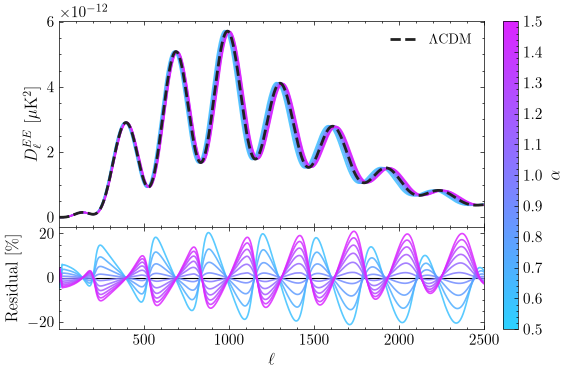

In [21]:
# E1: lensed C_ell^EE absolute + ratio (fixed h, theta_s NOT matched)
EE_l = fac * cl_l['ee']
EE_grea_cache = {
    at: fac * grea_instances[at].lensed_cl(lmax)['ee'] for at in SOLVED_ALPHAS}

fig, (ax, axr) = plt.subplots(2, 1, figsize=(6, 4), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.})
ax.plot(ell[mask], EE_l[mask], color=LCDM_COLOR, lw=2.,
        ls='--', label=r'$\Lambda$CDM', zorder=10)
axr.axhline(0, color='k', lw=0.8)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    EE_g = EE_grea_cache[at]
    ax.plot(ell[mask], EE_g[mask], color=col, lw=1.2, alpha=0.85)
    axr.plot(ell[mask], (EE_g[mask]/EE_l[mask] -
             1.) * 100, color=col, lw=1.2, alpha=0.85)
ax.margins(x=0)
ax.grid(False)
axr.grid(False)

# ax.set_xscale('log')
ax.set_ylabel(r'$D_\ell^{EE}$  [$\mu$K$^2$]')
ax.legend()
# axr.set_xscale('log')
axr.set_xlabel(r'$\ell$')
axr.set_ylabel(r'Residual [\%]')
add_alpha_colorbar(fig, (ax, axr))

save_fig(fig, 'E1_ClEE')
plt.show()

  saved -> E2_ClTE.pdf


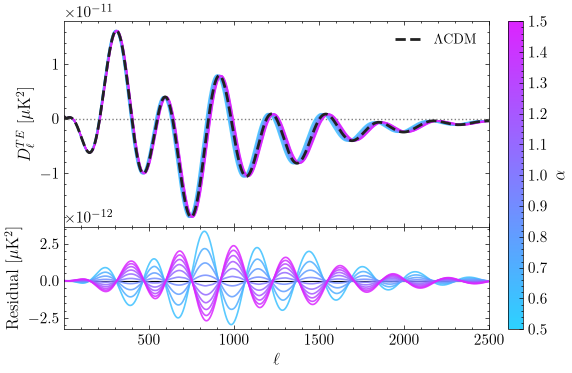

In [22]:
# E2: lensed C_ell^TE absolute + residual (fixed h, theta_s NOT matched)
# TE oscillates through zero, so an additive residual is used instead of a ratio
TE_l = fac * cl_l['te']
TE_grea_cache = {
    at: fac * grea_instances[at].lensed_cl(lmax)['te'] for at in SOLVED_ALPHAS}

fig, (ax, axr) = plt.subplots(2, 1, figsize=(6, 4), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.})
ax.axhline(0, color='grey', lw=1., ls=':')
ax.plot(ell[mask], TE_l[mask], color=LCDM_COLOR, lw=2.,
        ls='--', label=r'$\Lambda$CDM', zorder=10)
axr.axhline(0, color='k', lw=0.8)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    TE_g = TE_grea_cache[at]
    ax.plot(ell[mask], TE_g[mask], color=col, lw=1.2, alpha=0.85)
    axr.plot(ell[mask], TE_g[mask] - TE_l[mask],
             color=col, lw=1.2, alpha=0.85)
ax.margins(x=0)
ax.grid(False)
axr.grid(False)

# ax.set_xscale('log')
ax.set_ylabel(r'$D_\ell^{TE}$  [$\mu$K$^2$]')
ax.legend()
# axr.set_xscale('log')
axr.set_xlabel(r'$\ell$')
axr.set_ylabel(r'Residual [$\mu$K$^2$]')
add_alpha_colorbar(fig, (ax, axr))

save_fig(fig, 'E2_ClTE')
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\%'
<>:27: SyntaxWarning: invalid escape sequence '\%'
/var/folders/dk/vx1rnqkj33q9dmx22kf0szpr0000gn/T/ipykernel_1947/1366335272.py:27: SyntaxWarning: invalid escape sequence '\%'
  axr.set_ylabel('Residual [\%]')


  saved -> E3_ClBB.pdf


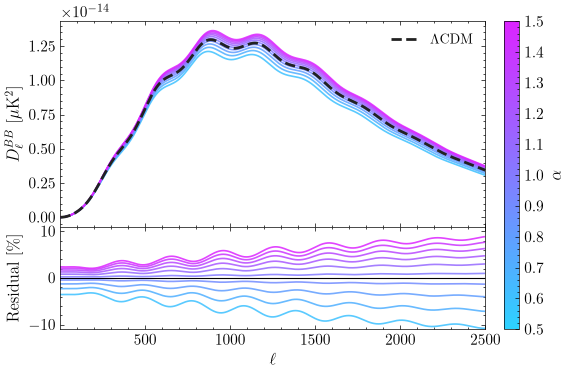

In [23]:
# E3: lensed C_ell^BB absolute + ratio (fixed h, theta_s NOT matched)
# No primordial tensors (r not set) -> BB here is purely lensing-induced (E -> B)
BB_l = fac * cl_l['bb']
BB_grea_cache = {
    at: fac * grea_instances[at].lensed_cl(lmax)['bb'] for at in SOLVED_ALPHAS}

fig, (ax, axr) = plt.subplots(2, 1, figsize=(6, 4), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.})
ax.plot(ell[mask], BB_l[mask], color=LCDM_COLOR, lw=2.,
        ls='--', label=r'$\Lambda$CDM', zorder=10)
axr.axhline(0, color='k', lw=0.8)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    BB_g = BB_grea_cache[at]
    ax.plot(ell[mask], BB_g[mask], color=col, lw=1.2, alpha=0.85)
    axr.plot(ell[mask], (BB_g[mask]/BB_l[mask] -
             1.) * 100, color=col, lw=1.2, alpha=0.85)
ax.margins(x=0)
ax.grid(False)
axr.grid(False)

# ax.set_xscale('log')
ax.set_ylabel(r'$D_\ell^{BB}$  [$\mu$K$^2$]')
ax.legend()
# axr.set_xscale('log')
axr.set_xlabel(r'$\ell$')
axr.set_ylabel('Residual [\%]')
axr.set_ylim(-11, 11)
axr.margins(x=0)
add_alpha_colorbar(fig, (ax, axr))

save_fig(fig, 'E3_ClBB')
plt.show()

---
## Section F — CMB Spectra with Hybrid log/linear ℓ Axis

Same GREA vs ΛCDM comparison as Sections D–E, but with a split x-axis:
**logarithmic for ℓ < 30** (Sachs-Wolfe plateau / large-scale ISW) and
**linear for ℓ ≥ 30** (acoustic peaks + damping tail).
The dotted vertical line marks the log↔linear transition at ℓ = 30.
`_tx`, `_ell_axis` are defined in F1 and reused by F2–F3.

<>:62: SyntaxWarning: invalid escape sequence '\%'
<>:62: SyntaxWarning: invalid escape sequence '\%'
/var/folders/dk/vx1rnqkj33q9dmx22kf0szpr0000gn/T/ipykernel_1947/1765657113.py:62: SyntaxWarning: invalid escape sequence '\%'
  axr.set_ylabel('Residual [\%]')


  saved -> F1_TT_splitax.pdf


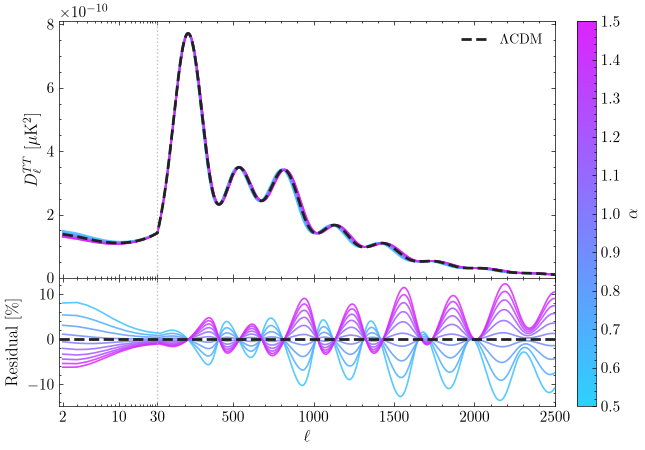

In [24]:

# F1: lensed C_ell^TT — hybrid log/linear ell axis
from matplotlib.ticker import FixedLocator

_ELL_BREAK = 30      # log <-> linear transition multipole
_LIN_SCALE = 0.002   # linear-region spacing in transformed coordinates


def _tx(arr):
    """Hybrid x-transform: log10(ell) for ell < 30, log10(30)+(ell-30)*scale for ell >= 30."""
    a = np.asarray(arr, dtype=float)
    log_b = np.log10(_ELL_BREAK)
    return np.where(a < _ELL_BREAK,
                    np.log10(np.maximum(a, 1e-9)),
                    log_b + (a - _ELL_BREAK) * _LIN_SCALE)


def _ell_axis(ax, xlabel=True):
    """Apply hybrid-scale ell ticks to ax (call on the bottom panel)."""
    major = np.array([2, 10, 30, 500, 1000, 1500, 2000, 2500])
    ax.set_xticks(_tx(major))
    ax.set_xticklabels([str(v) for v in major])
    minor_log = np.concatenate([np.arange(2, 10, 1), np.arange(10, 30, 2)])
    minor_lin = np.setdiff1d(np.arange(100, 2501, 100), major)
    ax.xaxis.set_minor_locator(FixedLocator(
        _tx(np.concatenate([minor_log, minor_lin]))))
    if xlabel:
        ax.set_xlabel(r'$\ell$')


_x = _tx(ell)
_xlim = (_tx(1.8), _tx(lmax))

fig, (ax, axr) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})

# main panel
ax.plot(_x[mask], TT_l[mask], color=LCDM_COLOR, lw=2., ls='--',
        label=r'$\Lambda$CDM', zorder=10)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    TT_g = TT_grea_cache[at]
    ax.plot(_x[mask], TT_g[mask], color=col, lw=1.2, alpha=0.85)

# residuals panel
axr.axhline(0, color=LCDM_COLOR, lw=2., ls='--', zorder=10)
for at in SOLVED_ALPHAS:
    TT_g = TT_grea_cache[at]
    axr.plot(_x[mask], (TT_g[mask] / TT_l[mask] - 1.) * 100,
             color=grea_color(at), lw=1.2, alpha=0.85)

# transition line + styling
for _a in (ax, axr):
    _a.axvline(_tx(_ELL_BREAK), color='darkgrey', ls=':', lw=1., alpha=0.7)
    _a.set_xlim(_xlim)
    _a.grid(False)

ax.set_ylim(bottom=0)
ax.set_ylabel(r'$D_\ell^{TT}$  [$\mu$K$^2$]')
ax.legend()
ax.tick_params(labelbottom=False)

axr.set_ylabel('Residual [\%]')
_ell_axis(axr)

add_alpha_colorbar(fig, (ax, axr))
save_fig(fig, 'F1_TT_splitax')
plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\%'
<>:25: SyntaxWarning: invalid escape sequence '\%'
/var/folders/dk/vx1rnqkj33q9dmx22kf0szpr0000gn/T/ipykernel_1947/678361008.py:25: SyntaxWarning: invalid escape sequence '\%'
  axr.set_ylabel('Residual [\%]')


  saved -> F2_EE_splitax.pdf


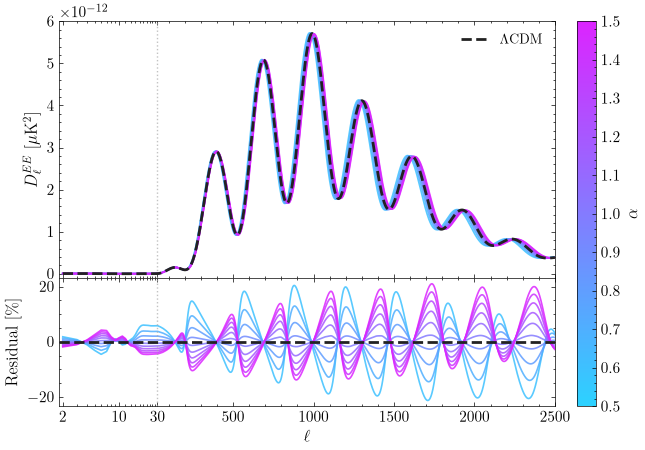

In [25]:

# F2: lensed C_ell^EE — hybrid log/linear ell axis  (requires F1 to have run)
fig, (ax, axr) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})

ax.plot(_x[mask], EE_l[mask], color=LCDM_COLOR, lw=2., ls='--',
        label=r'$\Lambda$CDM', zorder=10)
axr.axhline(0, color=LCDM_COLOR, lw=2., ls='--', zorder=10)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    EE_g = EE_grea_cache[at]
    ax.plot(_x[mask], EE_g[mask], color=col, lw=1.2, alpha=0.85)
    axr.plot(_x[mask], (EE_g[mask] / EE_l[mask] - 1.) * 100,
             color=col, lw=1.2, alpha=0.85)

for _a in (ax, axr):
    _a.axvline(_tx(_ELL_BREAK), color='darkgrey', ls=':', lw=1., alpha=0.7)
    _a.set_xlim(_xlim)
    _a.grid(False)

ax.set_ylim(-1e-13, 6e-12)
ax.set_ylabel(r'$D_\ell^{EE}$  [$\mu$K$^2$]')
ax.legend()
ax.tick_params(labelbottom=False)

axr.set_ylabel('Residual [\%]')
_ell_axis(axr)

add_alpha_colorbar(fig, (ax, axr))
save_fig(fig, 'F2_EE_splitax')
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\%'
<>:27: SyntaxWarning: invalid escape sequence '\%'
/var/folders/dk/vx1rnqkj33q9dmx22kf0szpr0000gn/T/ipykernel_1947/2904926301.py:27: SyntaxWarning: invalid escape sequence '\%'
  axr.set_ylabel('Residual [\%]')


  saved -> F3_BB_splitax.pdf


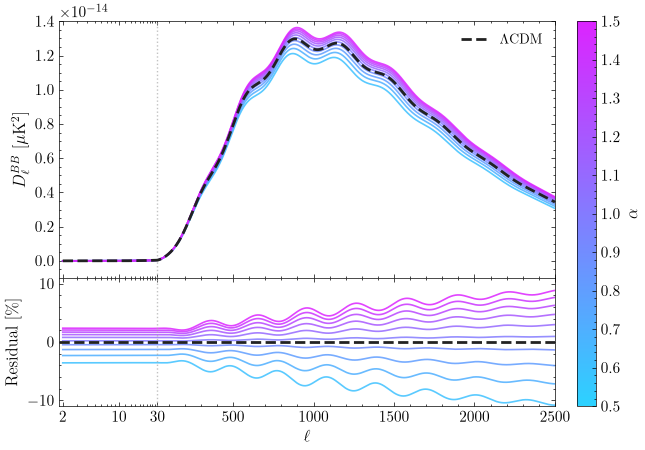

In [26]:

# F3: lensed C_ell^BB — hybrid log/linear ell axis  (requires F1 to have run)
# BB is purely lensing-induced (no primordial tensors) -> always positive -> ratio residual OK
fig, (ax, axr) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})

ax.plot(_x[mask], BB_l[mask], color=LCDM_COLOR, lw=2., ls='--',
        label=r'$\Lambda$CDM', zorder=10)
axr.axhline(0, color=LCDM_COLOR, lw=2., ls='--', zorder=10)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    BB_g = BB_grea_cache[at]
    ax.plot(_x[mask], BB_g[mask], color=col, lw=1.2, alpha=0.85)
    axr.plot(_x[mask], (BB_g[mask] / BB_l[mask] - 1.) * 100,
             color=col, lw=1.2, alpha=0.85)

for _a in (ax, axr):
    _a.axvline(_tx(_ELL_BREAK), color='darkgrey', ls=':', lw=1., alpha=0.7)
    _a.set_xlim(_xlim)
    _a.grid(False)

ax.set_ylim(-1e-15, 1.4e-14)
ax.set_ylabel(r'$D_\ell^{BB}$  [$\mu$K$^2$]')
ax.legend()
ax.tick_params(labelbottom=False)

axr.set_ylim(-11, 11)
axr.set_ylabel('Residual [\%]')
_ell_axis(axr)

add_alpha_colorbar(fig, (ax, axr))
save_fig(fig, 'F3_BB_splitax')
plt.show()

  saved -> F4_TE_splitax.pdf


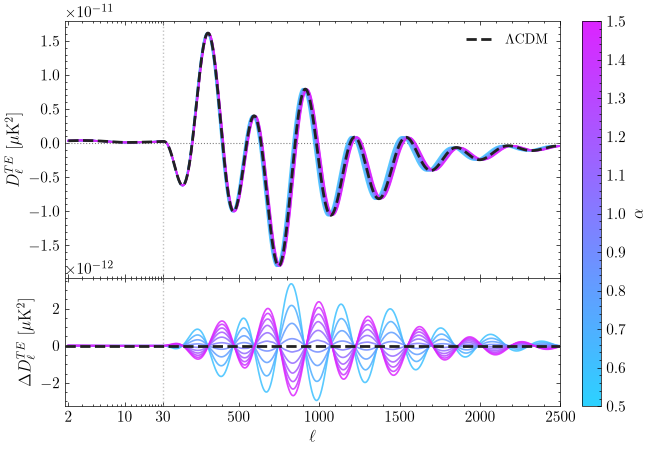

In [27]:

# F4: lensed C_ell^TE — hybrid log/linear ell axis  (requires F1 to have run)
# TE oscillates through zero -> ratio residual diverges at nulls; additive difference used instead
fig, (ax, axr) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})

ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.plot(_x[mask], TE_l[mask], color=LCDM_COLOR, lw=2., ls='--',
        label=r'$\Lambda$CDM', zorder=10)
axr.axhline(0, color=LCDM_COLOR, lw=2., ls='--', zorder=10)
for at in SOLVED_ALPHAS:
    col = grea_color(at)
    TE_g = TE_grea_cache[at]
    ax.plot(_x[mask], TE_g[mask], color=col, lw=1.2, alpha=0.85)
    axr.plot(_x[mask], TE_g[mask] - TE_l[mask], color=col, lw=1.2, alpha=0.85)

for _a in (ax, axr):
    _a.axvline(_tx(_ELL_BREAK), color='darkgrey', ls=':', lw=1., alpha=0.7)
    _a.set_xlim(_xlim)
    _a.grid(False)

ax.set_ylabel(r'$D_\ell^{TE}$  [$\mu$K$^2$]')
ax.legend()
ax.tick_params(labelbottom=False)

axr.set_ylabel(r'$\Delta D_\ell^{TE}$  [$\mu$K$^2$]')
_ell_axis(axr)

add_alpha_colorbar(fig, (ax, axr))
save_fig(fig, 'F4_TE_splitax')
plt.show()